In [1]:
# UKB PROJECTION + REGRESSION SCRIPT (UPDATED)
# 1) Loads the saved FINAL RF models + training metadata
# 2) Builds UKB X with EXACT training columns (missing cols -> NaN)
# 3) Coerces to numeric (strings -> NaN)
# 4) Uses the *trained* SimpleImputer inside each saved RF pipeline:
#    - If a whole column is missing in UKB (e.g., dog/cat), it becomes NaN,
#      and is imputed to the AGP median (constant for all UKB participants).
#    - If some entries are missing, those entries get AGP-median imputation.
# 5) Predicts PC_hat for UKB
# 6) Runs OLS regression: cognition ~ PC_hat (+ optional covariates)|

import os
import json
import joblib
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

# 0) Config
model_dir = "./RF_PCA_Trained_Models/"  # where the saved final_*.pkl and final_training_metadata.json
ukb_metadata_path = "variable_mapping/ukb_as_agp_metadata.csv"
ukb_index_col = "sample_name"

# outcome variable
cognition_col = "fluid_intelligence_score"
# cognition_col = "mean_match_rt_ms"

reg_covars = [
    "age_corrected",
    "race",
    #highest_education",
    #"country_of_birth"
]

out_dir = "./hongrui_result/UKB_RF_PCA_Projection/"
os.makedirs(out_dir, exist_ok=True)

# 1) LOAD SAVED MODELS + TRAINING METADATA
final_rf_models = joblib.load(os.path.join(model_dir, "final_rf_models.pkl"))

with open(os.path.join(model_dir, "final_training_metadata.json"), "r") as f:
    train_meta = json.load(f)

train_cols = train_meta["numeric_cols_used_as_X"]
n_pcs_to_predict = int(train_meta["n_pcs_to_implement"])

print(f"Loaded {len(final_rf_models)} RF models.")
print(f"Training expects {len(train_cols)} numeric metadata columns.")
print(f"Will predict {n_pcs_to_predict} PCs.")

# 2) LOAD UKB METADATA (AGP-LIKE)
ukb_df = pd.read_csv(ukb_metadata_path, index_col=ukb_index_col)
ukb_df["age_corrected"] = pd.to_numeric(ukb_df["age_corrected"], errors="coerce")

# Overwrite age_corrected with its mean-centered version
ukb_df["age_corrected"] = ukb_df["age_corrected"] - ukb_df["age_corrected"].mean()
print(f"Loaded UKB-like metadata: {ukb_df.shape[0]} rows, {ukb_df.shape[1]} columns.")

if cognition_col not in ukb_df.columns:
    raise ValueError(f"cognition_col='{cognition_col}' not found. Available cols include: {list(ukb_df.columns)[:30]} ...")

missing_covars = [c for c in reg_covars if c not in ukb_df.columns]
if missing_covars:
    raise ValueError(f"Missing regression covariates in UKB dataframe: {missing_covars}")

Loaded 10 RF models.
Training expects 27 numeric metadata columns.
Will predict 10 PCs.
Loaded UKB-like metadata: 502244 rows, 49 columns.


In [2]:
# Build covariates ONCE (consistent across OLS/baseline/permutation/logit)

cov_num = ["age_corrected"]                 # continuous
cov_cat = [
    "race",
    #"highest_education",
    #"country_of_birth"
]# categorical

# build cov_df
cov_df_num = ukb_df[cov_num].apply(pd.to_numeric, errors="coerce")
cov_df_cat = pd.get_dummies(
    ukb_df[cov_cat].astype("string").fillna("MISSING"),
    prefix=cov_cat,
    drop_first=True,
    dtype=float
)

cov_df = pd.concat([cov_df_num, cov_df_cat], axis=1)
cov_cols = list(cov_df.columns)
cov_df.head(5)

,age_corrected,race_Asian or Pacific Islander,race_Caucasian,race_Other
sample_name,,,,
1000565.0,-6.530963,1.0,0.0,0.0
1004472.0,-15.530963,0.0,1.0,0.0
1005221.0,9.469037,0.0,1.0,0.0
1006556.0,-0.530963,0.0,1.0,0.0
1006792.0,8.469037,0.0,1.0,0.0


In [3]:
# 2.5) ROW FILTERING BY MISSINGNESS
# - Decide which columns count toward per-row missingness
# - Skip the columns that AGP never trained on, these columns are the variable that I removed from AGP
# - Enforces outcome + covariates are present for regression

# Columns to IGNORE in the row-missingness calculation
# (edit this list and re-run this cell to see N change)

skip_cols = [
    "cat",
    "dog",
    "multivitamin",
    "other_supplement_frequency",
    "cosmetics_frequency",
    "fermented_plant_frequency",
    "homecooked_meals_frequency",
    "meat_eggs_frequency",
    "sugary_sweets_frequency",
    "vivid_dreams",
    "sugar_sweetened_drink_frequency",
    #"free_sugar_scaled_0_5",
    "artificial_sweeteners",
    #"one_liter_of_water_a_day_frequency",
    "olive_oil",
    "prepared_meals_frequency",
    "ready_to_eat_meals_frequency",
    #"probiotic_frequency",
    "whole_eggs",
    "frozen_dessert_frequency",
]

max_missing_frac = 0.15  # 10% missing allowed (i.e., >=90% complete)
required_for_regression = [cognition_col] + cov_num # these have to be present, otherwise, drop the row

def filter_rows_by_missingness(df, *, skip_cols=(), required_cols=(), max_missing_frac=0.10):
    # if a row has 10 percent of the data missing, keep it
    skip_cols = list(skip_cols)
    required_cols = list(required_cols)
    # warn if skip columns aren't present
    missing_skip = [c for c in skip_cols if c not in df.columns]
    if missing_skip:
        print(f"[WARN] skip_cols not in dataframe (ignored): {missing_skip[:10]}{'...' if len(missing_skip)>10 else ''}")
    # columns that count toward per-row missingness
    cols_check = [c for c in df.columns if c not in set(skip_cols)]
    if len(cols_check) == 0:
        raise ValueError("After applying skip_cols, cols_check is empty. Reduce skip_cols.")
    missing_frac = df[cols_check].isna().mean(axis=1)
    n_in = df.shape[0]
    mask = missing_frac <= max_missing_frac
    df_f = df.loc[mask].copy()
    # enforce outcome/covariates present
    required_present = [c for c in required_cols if c in df_f.columns]
    df_f = df_f.dropna(subset=required_present)
    n_out = df_f.shape[0]
    report = {
        "n_in": n_in,
        "n_out": n_out,
        "dropped": n_in - n_out,
        "cols_check_n": len(cols_check),
        "missing_frac_summary": missing_frac.describe().to_dict()
    }
    return df_f, report

ukb_df, miss_report = filter_rows_by_missingness(
    ukb_df,
    skip_cols=skip_cols,
    required_cols=required_for_regression,
    max_missing_frac=max_missing_frac
)

print("\n[ROW FILTER REPORT]")
print(f"Input rows:   {miss_report['n_in']}")
print(f"Output rows:  {miss_report['n_out']}")
print(f"Dropped rows: {miss_report['dropped']}")
print(f"Cols counted toward missingness: {miss_report['cols_check_n']}")
print("Missingness fraction summary (before filtering):")
print(pd.Series(miss_report["missing_frac_summary"]))

[WARN] skip_cols not in dataframe (ignored): ['cat', 'dog', 'multivitamin', 'other_supplement_frequency', 'cosmetics_frequency', 'fermented_plant_frequency', 'homecooked_meals_frequency', 'meat_eggs_frequency', 'sugary_sweets_frequency', 'vivid_dreams']

[ROW FILTER REPORT]
Input rows:   502244
Output rows:  118448
Dropped rows: 383796
Cols counted toward missingness: 42
Missingness fraction summary (before filtering):
count    502244.000000
mean          0.158176
std           0.055660
min           0.000000
25%           0.142857
50%           0.166667
75%           0.190476
max           0.666667
dtype: float64


In [4]:
# 3) BUILD UKB X MATRIX WITH EXACT TRAINING COLUMNS
X_ukb = ukb_df.reindex(columns=train_cols)
X_ukb = X_ukb.apply(pd.to_numeric, errors="coerce")

# Report how many entire columns are missing from UKB
missing_cols = [c for c in train_cols if c not in ukb_df.columns]
print(f"UKB is missing {len(missing_cols)} / {len(train_cols)} training columns.")
if len(missing_cols) > 0:
    print("First 25 missing training columns:", missing_cols[:25])

# Missingness after numeric coercion, before UKB imputation
missing_rate_before = float(np.mean(pd.isna(X_ukb.values)))
print(f"Overall missing rate in X_ukb before UKB imputation: {missing_rate_before*100:.2f}%")

# Impute UKB missing values using UKB column means
ukb_col_means = X_ukb.mean(axis=0)
X_ukb = X_ukb.fillna(ukb_col_means)

# Missingness after UKB mean imputation
missing_rate_after = float(np.mean(pd.isna(X_ukb.values)))
print(f"Overall missing rate in X_ukb after UKB mean imputation: {missing_rate_after*100:.2f}%")

# 4) PREDICT PC_hat FOR UKB|
pc_hat = pd.DataFrame(index=ukb_df.index)

for k in range(n_pcs_to_predict):
    pc_name = f"PC{k+1}"
    if pc_name not in final_rf_models:
        raise KeyError(f"Model for {pc_name} not found in final_rf_models.pkl (keys={list(final_rf_models.keys())[:5]}...)")
    pc_hat[f"{pc_name}_hat"] = final_rf_models[pc_name].predict(X_ukb)

pc_hat_path = os.path.join(out_dir, "ukb_predicted_microbiome_pcs.csv")
pc_hat.to_csv(pc_hat_path)
print(f"Saved predicted PCs to: {pc_hat_path}")

UKB is missing 0 / 27 training columns.
Overall missing rate in X_ukb before UKB imputation: 11.28%
Overall missing rate in X_ukb after UKB mean imputation: 0.00%
Saved predicted PCs to: ./hongrui_result/UKB_RF_PCA_Projection/ukb_predicted_microbiome_pcs.csv



=== Predicted PC correlation (Pearson), first 10 PCs ===
          PC1_hat  PC2_hat  PC3_hat  PC4_hat  PC5_hat  PC6_hat  PC7_hat  \
PC1_hat     1.000   -0.508    0.161   -0.231   -0.532    0.153    0.350   
PC2_hat    -0.508    1.000   -0.409   -0.072    0.363   -0.386   -0.240   
PC3_hat     0.161   -0.409    1.000    0.148   -0.384    0.659    0.175   
PC4_hat    -0.231   -0.072    0.148    1.000    0.356    0.095   -0.184   
PC5_hat    -0.532    0.363   -0.384    0.356    1.000   -0.487   -0.131   
PC6_hat     0.153   -0.386    0.659    0.095   -0.487    1.000   -0.020   
PC7_hat     0.350   -0.240    0.175   -0.184   -0.131   -0.020    1.000   
PC8_hat    -0.607    0.560   -0.453    0.268    0.612   -0.476   -0.443   
PC9_hat    -0.086    0.151   -0.016    0.283    0.299   -0.276    0.197   
PC10_hat   -0.062    0.055    0.148    0.005    0.083   -0.017    0.278   

          PC8_hat  PC9_hat  PC10_hat  
PC1_hat    -0.607   -0.086    -0.062  
PC2_hat     0.560    0.151     0.055  

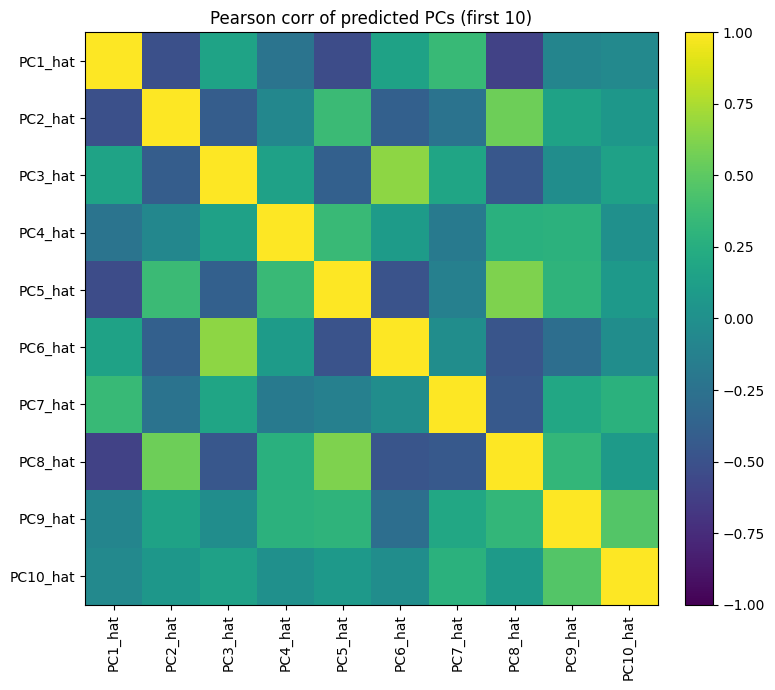

Saved correlation heatmap to: ./hongrui_result/UKB_RF_PCA_Projection/predicted_pc_corr_10x10.pdf
Max |off-diagonal corr| (first 10): 0.6586464223965848


In [5]:
# QC: Are predicted PCs correlated? (show 10x10 correlation)
# Put this RIGHT AFTER Step 4 loop that builds pc_hat

k_show = min(10, n_pcs_to_predict)
pc_first = [f"PC{i}_hat" for i in range(1, k_show + 1) if f"PC{i}_hat" in pc_hat.columns]

pc_first_df = pc_hat[pc_first].apply(pd.to_numeric, errors="coerce")

# 10x10 Pearson correlation matrix
corr_10x10 = pc_first_df.corr(method="pearson")

print("\n=== Predicted PC correlation (Pearson), first 10 PCs ===")
print(corr_10x10.round(3))

# Save matrix
corr_csv = os.path.join(out_dir, f"predicted_pc_corr_{k_show}x{k_show}.csv")
corr_10x10.to_csv(corr_csv)
print(f"Saved correlation matrix to: {corr_csv}")

# Optional: quick heatmap
plt.figure(figsize=(8, 7))
im = plt.imshow(corr_10x10.values, vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(pc_first)), pc_first, rotation=90)
plt.yticks(range(len(pc_first)), pc_first)
plt.title(f"Pearson corr of predicted PCs (first {k_show})")
plt.tight_layout()
corr_pdf = os.path.join(out_dir, f"predicted_pc_corr_{k_show}x{k_show}.pdf")
plt.savefig(corr_pdf)
plt.show()
plt.close()
print(f"Saved correlation heatmap to: {corr_pdf}")

# Optional: single-number summary (max off-diagonal abs corr)
vals = corr_10x10.values.copy()
np.fill_diagonal(vals, 0.0)
print("Max |off-diagonal corr| (first 10):", float(np.nanmax(np.abs(vals))))

In [6]:
# ============================================================
# 5) OLS REGRESSION (HC3): cognition ~ PC_hat + covariates
# - age_corrected treated as CONTINUOUS
# - race + country_of_birth treated as CATEGORICAL (one-hot)
# - uses a single dropna() so sample is consistent
# ============================================================

# Outcome
y = pd.to_numeric(ukb_df[cognition_col], errors="coerce")
pc_cols = [c for c in pc_hat.columns if c.endswith("_hat")]
pc_hat_num = pc_hat[pc_cols].apply(pd.to_numeric, errors="coerce") # make sure predicted PC is numerical

X_reg = pd.concat([pc_hat_num, cov_df], axis=1) # full regression matrix
X_reg = sm.add_constant(X_reg, has_constant="add") # add intercept for the sm.OLS model
X_reg = X_reg.replace([np.inf, -np.inf], np.nan)
X_reg = X_reg.apply(pd.to_numeric, errors="coerce") # make sure everything is numeric

# Single analysis dataframe (locks sample)
data = pd.concat([y.rename("y"), X_reg], axis=1).dropna()

print("Rows used in regression:", data.shape[0], "Cols:", data.shape[1])
if data.shape[0] == 0:
    raise ValueError("No rows left after dropna. Check missingness in y / PCs / covariates.")

y_clean = data["y"].astype(float)
X_clean = data.drop(columns=["y"]).astype(float)

fit = sm.OLS(y_clean, X_clean).fit()
print(fit.summary())

summary_path = os.path.join(out_dir, "ukb_cognition_on_predicted_pcs_summary.txt")
with open(summary_path, "w") as f:
    f.write(fit.summary().as_text())
print(f"Saved regression summary to: {summary_path}")

Rows used in regression: 118448 Cols: 16
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     490.9
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:58:55   Log-Likelihood:            -2.5212e+05
No. Observations:              118448   AIC:                         5.043e+05
Df Residuals:                  118433   BIC:                         5.044e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

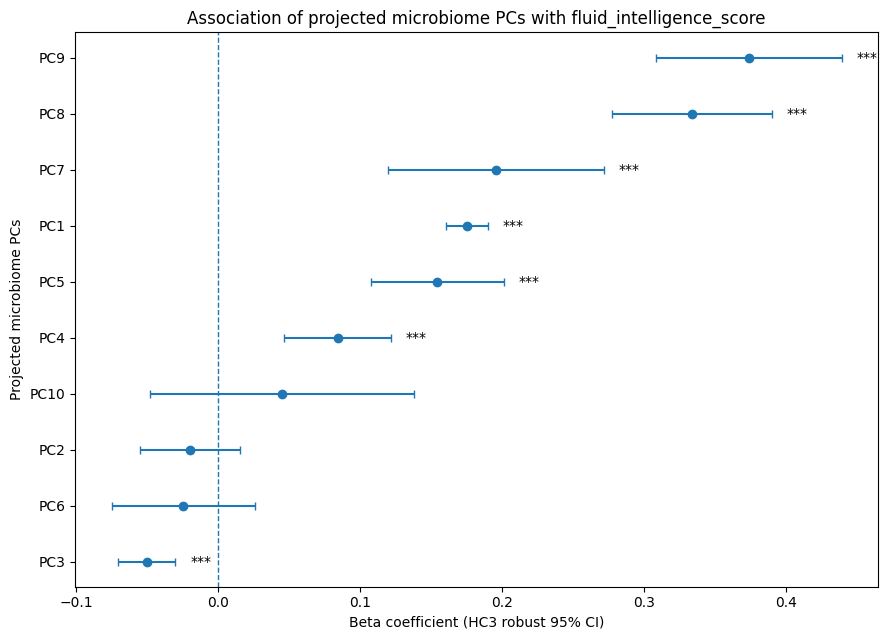

Saved forest plot PNG to: ./hongrui_result/UKB_RF_PCA_Projection/ukb_cognition_projected_pc_forestplot.png
Saved forest plot PDF to: ./hongrui_result/UKB_RF_PCA_Projection/ukb_cognition_projected_pc_forestplot.pdf


In [7]:
# ============================================================
# 6) FOREST PLOT (paper-style): projected PC_hat coefficients
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

coef_df = pd.DataFrame({
    "term": fit.params.index,
    "beta": fit.params.values,
    "pval": fit.pvalues.values
})

ci = fit.conf_int()
ci.columns = ["ci_low", "ci_high"]
coef_df = coef_df.merge(ci, left_on="term", right_index=True, how="left")

forest_df = coef_df[coef_df["term"].isin(pc_cols)].copy()

if forest_df.empty:
    raise ValueError("No projected PC terms found in fit.params. Check pc_cols naming.")

def p_to_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""

forest_df["stars"] = forest_df["pval"].apply(p_to_star)

# nicer labels
forest_df["label"] = forest_df["term"].str.replace("_hat", "", regex=False)

# sort by beta
forest_df = forest_df.sort_values("beta", ascending=True).reset_index(drop=True)

fig_h = max(4, 0.5 * len(forest_df) + 1.5)
fig, ax = plt.subplots(figsize=(9, fig_h))

ypos = np.arange(len(forest_df))

ax.errorbar(
    x=forest_df["beta"],
    y=ypos,
    xerr=[
        forest_df["beta"] - forest_df["ci_low"],
        forest_df["ci_high"] - forest_df["beta"]
    ],
    fmt="o",
    capsize=3,
    linewidth=1.5
)

ax.axvline(0, linestyle="--", linewidth=1)

ax.set_yticks(ypos)
ax.set_yticklabels(forest_df["label"])
ax.set_xlabel("Beta coefficient (HC3 robust 95% CI)")
ax.set_ylabel("Projected microbiome PCs")
ax.set_title(f"Association of projected microbiome PCs with {cognition_col}")

# add significance stars to the right of each CI
x_pad = 0.02 * (forest_df["ci_high"].max() - forest_df["ci_low"].min() + 1e-8)
for i, row in forest_df.iterrows():
    if row["stars"] != "":
        ax.text(row["ci_high"] + x_pad, i, row["stars"], va="center", fontsize=10)

plt.tight_layout()

forest_png = os.path.join(out_dir, "ukb_cognition_projected_pc_forestplot.png")
forest_pdf = os.path.join(out_dir, "ukb_cognition_projected_pc_forestplot.pdf")

plt.savefig(forest_png, dpi=300, bbox_inches="tight")
plt.savefig(forest_pdf, bbox_inches="tight")
plt.show()

print(f"Saved forest plot PNG to: {forest_png}")
print(f"Saved forest plot PDF to: {forest_pdf}")

In [8]:
'''
tmp = pd.concat(
    [ukb_df[[cognition_col]].rename(columns={cognition_col:"y"}),
     ukb_df[["age_corrected"]]],
    axis=1
).apply(pd.to_numeric, errors="coerce").dropna()

fit_age_only = sm.OLS(tmp["y"], sm.add_constant(tmp[["age_corrected"]])).fit()
print(fit_age_only.summary())
'''

'\ntmp = pd.concat(\n    [ukb_df[[cognition_col]].rename(columns={cognition_col:"y"}),\n     ukb_df[["age_corrected"]]],\n    axis=1\n).apply(pd.to_numeric, errors="coerce").dropna()\n\nfit_age_only = sm.OLS(tmp["y"], sm.add_constant(tmp[["age_corrected"]])).fit()\nprint(fit_age_only.summary())\n'

In [9]:
# ============================================================
# 5b) OLS REGRESSION (HC3): cognition ~ ONE PC_hat AT A TIME + covariates
# - uses the SAME covariates as your main model
# - by default locks the sample across all PCs for fair comparison
# - outputs a per-PC results table + optional full summaries
# ============================================================

# CONFIG
lock_same_sample = True   # True = same rows for all PC models (recommended for comparability)
save_each_summary = True  # save one txt summary per PC

# Outcome + predictors
y = pd.to_numeric(ukb_df[cognition_col], errors="coerce")
pc_cols = [c for c in pc_hat.columns if c.endswith("_hat")]
pc_hat_num = pc_hat[pc_cols].apply(pd.to_numeric, errors="coerce")

# Baseline model first: y ~ covariates only
X_base = sm.add_constant(cov_df.copy(), has_constant="add")
X_base = X_base.replace([np.inf, -np.inf], np.nan)
X_base = X_base.apply(pd.to_numeric, errors="coerce")

base_data = pd.concat([y.rename("y"), X_base], axis=1).dropna()

if base_data.shape[0] == 0:
    raise ValueError("No rows left for baseline model after dropna().")

fit_base = sm.OLS(base_data["y"].astype(float),
                  base_data.drop(columns=["y"]).astype(float)).fit()

baseline_r2 = fit_base.rsquared
baseline_adj_r2 = fit_base.rsquared_adj

print("Baseline model fitted.")
print("Baseline N:", base_data.shape[0])
print("Baseline R^2:", round(baseline_r2, 6))
print("Baseline adj R^2:", round(baseline_adj_r2, 6))

# -----------------------------
# Optional: lock the sample across ALL PCs + covariates + y
# This makes the per-PC results directly comparable.
# -----------------------------
if lock_same_sample:
    locked_data = pd.concat(
        [y.rename("y"), pc_hat_num, cov_df],
        axis=1
    ).replace([np.inf, -np.inf], np.nan)

    locked_data = locked_data.apply(pd.to_numeric, errors="coerce").dropna()

    print("\nLocked-sample mode ON")
    print("Rows used for every one-PC model:", locked_data.shape[0])

    if locked_data.shape[0] == 0:
        raise ValueError("No rows left in locked_data after dropna().")

# -----------------------------
# Fit one-PC-at-a-time models
# -----------------------------
results = []

single_pc_dir = os.path.join(out_dir, "single_pc_summaries")
os.makedirs(single_pc_dir, exist_ok=True)

for pc in pc_cols:
    if lock_same_sample:
        this_data = locked_data.copy()
        y_clean = this_data["y"].astype(float)

        X_this = pd.concat(
            [this_data[[pc]], this_data[cov_df.columns]],
            axis=1
        )
        X_this = sm.add_constant(X_this, has_constant="add").astype(float)

    else:
        # Each PC gets its own maximal sample size
        X_this = pd.concat([pc_hat_num[[pc]], cov_df], axis=1)
        X_this = sm.add_constant(X_this, has_constant="add")
        X_this = X_this.replace([np.inf, -np.inf], np.nan)
        X_this = X_this.apply(pd.to_numeric, errors="coerce")

        this_data = pd.concat([y.rename("y"), X_this], axis=1).dropna()

        if this_data.shape[0] == 0:
            print(f"Skipping {pc}: no rows left after dropna().")
            continue

        y_clean = this_data["y"].astype(float)
        X_this = this_data.drop(columns=["y"]).astype(float)

    fit_pc = sm.OLS(y_clean, X_this).fit()

    # pull coefficient info for this PC
    beta = fit_pc.params.get(pc, np.nan)
    se = fit_pc.bse.get(pc, np.nan)
    tval = fit_pc.tvalues.get(pc, np.nan)
    pval = fit_pc.pvalues.get(pc, np.nan)
    ci_low, ci_high = fit_pc.conf_int().loc[pc].tolist()

    # compare against baseline
    delta_r2 = fit_pc.rsquared - baseline_r2
    delta_adj_r2 = fit_pc.rsquared_adj - baseline_adj_r2

    results.append({
        "pc": pc,
        "n": int(len(y_clean)),
        "beta": beta,
        "se_hc3": se,
        "t_hc3": tval,
        "p_value": pval,
        "ci_low_95": ci_low,
        "ci_high_95": ci_high,
        "r2": fit_pc.rsquared,
        "adj_r2": fit_pc.rsquared_adj,
        "delta_r2_vs_baseline": delta_r2,
        "delta_adj_r2_vs_baseline": delta_adj_r2,
    })

    if save_each_summary:
        summary_file = os.path.join(single_pc_dir, f"{pc}_summary.txt")
        with open(summary_file, "w") as f:
            f.write(fit_pc.summary().as_text())

# Build summary table
single_pc_results = pd.DataFrame(results)

if single_pc_results.empty:
    raise ValueError("No one-PC models were successfully fit.")

# Multiple-testing correction
reject, qvals, _, _ = multipletests(single_pc_results["p_value"], method="fdr_bh")
single_pc_results["q_value_BH"] = qvals
single_pc_results["reject_FDR_0p05"] = reject

# Two useful sortings
single_pc_results_by_p = single_pc_results.sort_values(["p_value", "delta_r2_vs_baseline"])
single_pc_results_by_r2 = single_pc_results.sort_values(
    ["delta_r2_vs_baseline", "p_value"],
    ascending=[False, True]
)

print("\n=== One-PC-at-a-time results: ranked by p-value ===")
display(single_pc_results_by_p)

print("\n=== One-PC-at-a-time results: ranked by delta R^2 vs baseline ===")
display(single_pc_results_by_r2)

# Save both versions
out_csv_p = os.path.join(out_dir, "ukb_cognition_one_pc_at_a_time_ranked_by_p.csv")
out_csv_r2 = os.path.join(out_dir, "ukb_cognition_one_pc_at_a_time_ranked_by_delta_r2.csv")

single_pc_results_by_p.to_csv(out_csv_p, index=False)
single_pc_results_by_r2.to_csv(out_csv_r2, index=False)

print(f"\nSaved ranked-by-p table to: {out_csv_p}")
print(f"Saved ranked-by-delta-R2 table to: {out_csv_r2}")

if save_each_summary:
    print(f"Saved individual model summaries to: {single_pc_dir}")

Baseline model fitted.
Baseline N: 118448
Baseline R^2: 0.042327
Baseline adj R^2: 0.042295

Locked-sample mode ON
Rows used for every one-PC model: 118448

=== One-PC-at-a-time results: ranked by p-value ===


,pc,n,beta,se_hc3,t_hc3,p_value,ci_low_95,ci_high_95,r2,adj_r2,delta_r2_vs_baseline,delta_adj_r2_vs_baseline,q_value_BH,reject_FDR_0p05
8,PC9_hat,118448,0.631043,0.024898,25.345003,2.436415e-141,0.582243,0.679843,0.047493,0.047453,0.005166,0.005158,2.436415e-140,True
5,PC6_hat,118448,-0.319303,0.016476,-19.380083,1.532308e-83,-0.351595,-0.287011,0.045355,0.045314,0.003027,0.003019,7.661538e-83,True
0,PC1_hat,118448,0.077390,0.005115,15.128881,1.167650e-51,0.067364,0.087417,0.044174,0.044134,0.001847,0.001839,3.892167e-51,True
2,PC3_hat,118448,-0.097126,0.006969,-13.936240,4.134333e-44,-0.110786,-0.083466,0.043895,0.043855,0.001568,0.001560,1.033583e-43,True
4,PC5_hat,118448,0.209798,0.015768,13.305156,2.309715e-40,0.178893,0.240704,0.043757,0.043716,0.001429,0.001421,4.619431e-40,True
7,PC8_hat,118448,0.202314,0.015644,12.932657,3.125758e-38,0.171653,0.232976,0.043678,0.043637,0.001350,0.001342,5.209597e-38,True
6,PC7_hat,118448,0.275615,0.029482,9.348505,9.037275e-21,0.217830,0.333400,0.043033,0.042993,0.000706,0.000698,1.291039e-20,True
9,PC10_hat,118448,0.358589,0.039587,9.058166,1.346062e-19,0.280998,0.436180,0.042990,0.042950,0.000663,0.000655,1.682577e-19,True
3,PC4_hat,118448,0.126553,0.015270,8.287720,1.166283e-16,0.096624,0.156482,0.042882,0.042842,0.000555,0.000547,1.295871e-16,True
1,PC2_hat,118448,0.008411,0.013512,0.622472,5.336325e-01,-0.018073,0.034895,0.042330,0.042290,0.000003,-0.000005,5.336325e-01,False



=== One-PC-at-a-time results: ranked by delta R^2 vs baseline ===


,pc,n,beta,se_hc3,t_hc3,p_value,ci_low_95,ci_high_95,r2,adj_r2,delta_r2_vs_baseline,delta_adj_r2_vs_baseline,q_value_BH,reject_FDR_0p05
8,PC9_hat,118448,0.631043,0.024898,25.345003,2.436415e-141,0.582243,0.679843,0.047493,0.047453,0.005166,0.005158,2.436415e-140,True
5,PC6_hat,118448,-0.319303,0.016476,-19.380083,1.532308e-83,-0.351595,-0.287011,0.045355,0.045314,0.003027,0.003019,7.661538e-83,True
0,PC1_hat,118448,0.077390,0.005115,15.128881,1.167650e-51,0.067364,0.087417,0.044174,0.044134,0.001847,0.001839,3.892167e-51,True
2,PC3_hat,118448,-0.097126,0.006969,-13.936240,4.134333e-44,-0.110786,-0.083466,0.043895,0.043855,0.001568,0.001560,1.033583e-43,True
4,PC5_hat,118448,0.209798,0.015768,13.305156,2.309715e-40,0.178893,0.240704,0.043757,0.043716,0.001429,0.001421,4.619431e-40,True
7,PC8_hat,118448,0.202314,0.015644,12.932657,3.125758e-38,0.171653,0.232976,0.043678,0.043637,0.001350,0.001342,5.209597e-38,True
6,PC7_hat,118448,0.275615,0.029482,9.348505,9.037275e-21,0.217830,0.333400,0.043033,0.042993,0.000706,0.000698,1.291039e-20,True
9,PC10_hat,118448,0.358589,0.039587,9.058166,1.346062e-19,0.280998,0.436180,0.042990,0.042950,0.000663,0.000655,1.682577e-19,True
3,PC4_hat,118448,0.126553,0.015270,8.287720,1.166283e-16,0.096624,0.156482,0.042882,0.042842,0.000555,0.000547,1.295871e-16,True
1,PC2_hat,118448,0.008411,0.013512,0.622472,5.336325e-01,-0.018073,0.034895,0.042330,0.042290,0.000003,-0.000005,5.336325e-01,False



Saved ranked-by-p table to: ./hongrui_result/UKB_RF_PCA_Projection/ukb_cognition_one_pc_at_a_time_ranked_by_p.csv
Saved ranked-by-delta-R2 table to: ./hongrui_result/UKB_RF_PCA_Projection/ukb_cognition_one_pc_at_a_time_ranked_by_delta_r2.csv
Saved individual model summaries to: ./hongrui_result/UKB_RF_PCA_Projection/single_pc_summaries


In [10]:
print(ukb_df["age_corrected"].dtype)
print(ukb_df["age_corrected"].describe())
print("nunique:", ukb_df["age_corrected"].nunique())

float64
count    118448.000000
mean         -0.525526
std           8.131712
min         -16.530963
25%          -7.530963
50%           0.469037
75%           6.469037
max          13.469037
Name: age_corrected, dtype: float64
nunique: 31


In [11]:
# 6) BASELINE MODEL (covariates only) — continuous age + categorical dummies
y_base = pd.to_numeric(ukb_df[cognition_col], errors="coerce")

X_base = sm.add_constant(cov_df, has_constant="add")
X_base = X_base.replace([np.inf, -np.inf], np.nan)
X_base = X_base.apply(pd.to_numeric, errors="coerce")

base_data = pd.concat([y_base.rename("y"), X_base], axis=1).dropna()
print("Rows used in BASELINE regression:", base_data.shape[0], "Cols:", base_data.shape[1])

fit_base = sm.OLS(
    base_data["y"].astype(float),
    base_data.drop(columns=["y"]).astype(float)
).fit()

print(fit_base.summary())

Rows used in BASELINE regression: 118448 Cols: 6
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     1309.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:58:56   Log-Likelihood:            -2.5290e+05
No. Observations:              118448   AIC:                         5.058e+05
Df Residuals:                  118443   BIC:                         5.058e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [12]:
# ============================================================
# PERMUTATION TEST (Freedman–Lane): PCs add nothing beyond covariates
# - Fits baseline: y ~ covariates
# - Permutes baseline residuals
# - Re-fits full: y_perm ~ covariates + PC_hat
# - Tests joint Wald for PC terms + min single-PC p
# ============================================================

# config
B = 1000
seed = 42
rng = np.random.default_rng(seed)

pc_cols = [c for c in pc_hat.columns if c.endswith("_hat")]  # PC1_hat..PCk_hat

# ---- Reuse the SAME covariate design as the main OLS regression ----
cov_parts = []

if len(cov_num) > 0:
    cov_parts.append(ukb_df[cov_num].apply(pd.to_numeric, errors="coerce"))

if len(cov_cat) > 0:
    cov_parts.append(
        pd.get_dummies(
            ukb_df[cov_cat].astype("string").fillna("MISSING"),
            prefix=cov_cat,
            drop_first=True,
            dtype=float
        )
    )

cov_df = pd.concat(cov_parts, axis=1) if cov_parts else pd.DataFrame(index=ukb_df.index)

# ---- Build one analysis dataframe (locks sample) ----
df = pd.concat(
    [
        ukb_df[[cognition_col]].rename(columns={cognition_col: "y"}),
        pc_hat[pc_cols].apply(pd.to_numeric, errors="coerce"),
        cov_df
    ],
    axis=1
).replace([np.inf, -np.inf], np.nan)

df["y"] = pd.to_numeric(df["y"], errors="coerce")
df = df.dropna()

y = df["y"].astype(float)

cov_cols = list(cov_df.columns)  # after get_dummies
X_base = sm.add_constant(df[cov_cols], has_constant="add") if cov_cols else sm.add_constant(pd.DataFrame(index=df.index), has_constant="add")
X_full = sm.add_constant(df[pc_cols + cov_cols], has_constant="add") if cov_cols else sm.add_constant(df[pc_cols], has_constant="add")

def fit_ols_hc3(yvec, Xmat):
    return sm.OLS(yvec, Xmat).fit()

def joint_wald_stat(fit, cols_to_test):
    param_names = list(fit.params.index)
    R = np.zeros((len(cols_to_test), len(param_names)))
    for i, col in enumerate(cols_to_test):
        R[i, param_names.index(col)] = 1.0
    w = fit.wald_test(R, scalar=True)
    return float(w.statistic)

# ---- Observed (full) ----
fit_obs = fit_ols_hc3(y, X_full)
obs_joint = joint_wald_stat(fit_obs, pc_cols)
obs_pvals = fit_obs.pvalues[pc_cols].copy()
obs_minp = float(obs_pvals.min())

print("Observed R2 (full):", float(fit_obs.rsquared))
print("Observed joint Wald stat (PCs):", obs_joint)
print("Observed min single-PC p:", obs_minp)

# ---- Freedman–Lane permutations ----
# baseline fit: y ~ covariates
fit_base = fit_ols_hc3(y, X_base)
yhat = fit_base.fittedvalues
resid = y - yhat

perm_joint = np.empty(B)
perm_minp  = np.empty(B)
perm_sig_counts = {c: 0 for c in pc_cols}

resid_vals = resid.values

for b in range(B):
    resid_perm = rng.permutation(resid_vals)
    y_perm = yhat.values + resid_perm

    fit_b = fit_ols_hc3(y_perm, X_full)
    perm_joint[b] = joint_wald_stat(fit_b, pc_cols)

    pvals_b = fit_b.pvalues[pc_cols].values
    perm_minp[b] = float(np.min(pvals_b))

    for col, pv in zip(pc_cols, pvals_b):
        if pv < 0.05:
            perm_sig_counts[col] += 1

p_emp_joint = (1.0 + np.sum(perm_joint >= obs_joint)) / (B + 1.0)
p_emp_minp  = (1.0 + np.sum(perm_minp <= obs_minp)) / (B + 1.0)

print("\n--- Permutation results (Freedman–Lane) ---")
print(f"Permutations: {B}")
print(f"Empirical p (JOINT PCs | covariates): {p_emp_joint:.4g}")
print(f"Empirical p (MIN single-PC p): {p_emp_minp:.4g}")

sig_rates = pd.Series({col: perm_sig_counts[col] / B for col in pc_cols}).sort_values(ascending=False)
print("\nNull significance rate per PC at alpha=0.05 (should be ~0.05):")
print(sig_rates)

Observed R2 (full): 0.05484952305106694
Observed joint Wald stat (PCs): 156.91082290583722
Observed min single-PC p: 3.227258481332754e-120

--- Permutation results (Freedman–Lane) ---
Permutations: 1000
Empirical p (JOINT PCs | covariates): 0.000999
Empirical p (MIN single-PC p): 0.000999

Null significance rate per PC at alpha=0.05 (should be ~0.05):
PC2_hat     0.065
PC1_hat     0.056
PC8_hat     0.054
PC7_hat     0.052
PC10_hat    0.049
PC6_hat     0.048
PC9_hat     0.048
PC3_hat     0.047
PC5_hat     0.047
PC4_hat     0.037
dtype: float64


In [13]:
# other outcome we are interested in
binary_outcomes = [
    "ibs",
    "crohns_disease",
    "ulcerative_colitis",
    "dementia_general",
]

# --- Precompute predictors once (numeric PCs + encoded covariates) ---
pc_cols = [c for c in pc_hat.columns if c.endswith("_hat")]
pc_hat_num = pc_hat[pc_cols].apply(pd.to_numeric, errors="coerce")

# Build cov_df ONCE (continuous + categorical) — IMPORTANT: do NOT cast age to string
cov_parts = []

# numeric continuous covariates
if "cov_num" in globals() and len(cov_num) > 0:
    cov_num_df = ukb_df[cov_num].apply(pd.to_numeric, errors="coerce")
    cov_parts.append(cov_num_df)

# categorical covariates
if "cov_cat" in globals() and len(cov_cat) > 0:
    cov_cat_df = pd.get_dummies(
        ukb_df[cov_cat].astype("string").fillna("MISSING"),
        prefix=cov_cat,
        drop_first=True,
        dtype=float
    )
    cov_parts.append(cov_cat_df)

cov_df = pd.concat(cov_parts, axis=1) if cov_parts else pd.DataFrame(index=ukb_df.index)
cov_cols = list(cov_df.columns)

def joint_wald_pvalue(fit, cols_to_test):
    """H0: all coefficients of cols_to_test are 0 (joint Wald test)."""
    param_names = list(fit.params.index)
    R = np.zeros((len(cols_to_test), len(param_names)))
    for i, col in enumerate(cols_to_test):
        if col in param_names:
            R[i, param_names.index(col)] = 1.0
    w = fit.wald_test(R, scalar=True)
    return float(w.pvalue)

def fit_logit_with_fallback(y, X):
    """
    Try standard Logit + HC3 robust SE first.
    If that fails, try L1 regularized with alpha=0.0, then alpha=0.1.

    Returns
    -------
    fit_result
    fit_method : str
        One of:
        - "standard_logit_hc3"
        - "l1_regularized"
    alpha_used : float
        np.nan for standard fit, otherwise the alpha used in fit_regularized
    failure_reason : str or None
        Error message from the standard fit path if it failed
    """
    try:
        res = sm.Logit(y, X).fit(disp=0, maxiter=200)
        res_rob = res.get_robustcov_results(cov_type="HC3")
        return res_rob, "standard_logit_hc3", np.nan, None

    except Exception as e1:
        failure_reason = repr(e1)

        try:
            res_reg = sm.Logit(y, X).fit_regularized(
                method="l1",
                alpha=0.0,
                disp=0
            )
            return res_reg, "l1_regularized", 0.0, failure_reason

        except Exception as e2:
            failure_reason = failure_reason + " || alpha_0_failed: " + repr(e2)

            res_reg = sm.Logit(y, X).fit_regularized(
                method="l1",
                alpha=0.1,
                disp=0
            )
            return res_reg, "l1_regularized", 0.1, failure_reason

def coerce_binary(series):
    """Return 0/1 int series or None if not binary."""
    s = pd.to_numeric(series, errors="coerce")
    s2 = s.dropna()
    uniq = sorted(s2.unique().tolist())
    if len(uniq) == 0:
        return None
    if set(uniq).issubset({0, 1}):
        return s.astype("Int64")  # allow NA
    if set(uniq).issubset({1, 2}):
        return (s - 1).astype("Int64")
    return None

# --- Hard Code Dementia ---
dementia_subtypes = [
    "dementia_alzheimers",
    "dementia_vascular",
    "dementia_other",
    "dementia_unspecified"
]

missing_dementia_cols = [c for c in dementia_subtypes if c not in ukb_df.columns]
if missing_dementia_cols:
    print(f"[WARN] Missing dementia subtype columns: {missing_dementia_cols}")

present_dementia_cols = [c for c in dementia_subtypes if c in ukb_df.columns]
if len(present_dementia_cols) == 0:
    raise ValueError("No dementia subtype columns found in ukb_df.")

# Coerce each subtype to 0/1 first
dementia_bin_parts = {}
for c in present_dementia_cols:
    s = coerce_binary(ukb_df[c])
    if s is None:
        raise ValueError(f"{c} is not binary-coded as 0/1 or 1/2.")
    dementia_bin_parts[c] = s

dementia_bin_df = pd.DataFrame(dementia_bin_parts, index=ukb_df.index)

# Union across subtype columns:
# 1 if ANY dementia subtype is positive, else 0
# Do NOT sum, because the same person could have more than one subtype flag
ukb_df["dementia_general"] = dementia_bin_df.fillna(0).max(axis=1).astype("Int64")

# If all subtype fields are missing for a row, keep the combined outcome as missing
all_dem_missing = dementia_bin_df.isna().all(axis=1)
ukb_df.loc[all_dem_missing, "dementia_general"] = pd.NA

print("\nCombined dementia_general counts:")
print(ukb_df["dementia_general"].value_counts(dropna=False))

logit_outcome_rows = []
logit_pc_rows = []

for outcome in binary_outcomes:
    if outcome not in ukb_df.columns:
        print(f"[SKIP] {outcome} not found in ukb_df columns.")
        continue

    # Build modeling dataframe using precomputed predictors
    df_log = pd.concat(
        [
            ukb_df[[outcome]].rename(columns={outcome: "y"}),
            pc_hat_num,
            cov_df
        ],
        axis=1
    ).replace([np.inf, -np.inf], np.nan)

    # Coerce y to binary
    y_bin = coerce_binary(df_log["y"])
    if y_bin is None:
        print(f"[SKIP] {outcome}: not binary-coded (expected 0/1 or 1/2).")
        continue
    df_log["y"] = y_bin

    # Drop missing rows (locks sample for this outcome)
    needed = ["y"] + pc_cols + cov_cols
    df_log = df_log.dropna(subset=needed)
    if df_log.shape[0] == 0:
        print(f"[SKIP] {outcome}: no complete rows after dropna.")
        continue

    y_vec = df_log["y"].astype(int)
    n = int(len(y_vec))
    n_cases = int(y_vec.sum())
    n_controls = n - n_cases

    if n_cases == 0 or n_controls == 0:
        print(f"[SKIP] {outcome}: degenerate (cases={n_cases}, controls={n_controls}).")
        continue

    # Design matrix: PCs + covariates
    Xmat = df_log[pc_cols + cov_cols].astype(float)
    Xmat = sm.add_constant(Xmat, has_constant="add")

    # Fit
    fit_res, fit_method, alpha_used, failure_reason = fit_logit_with_fallback(y_vec, Xmat)
    used_reg = (fit_method != "standard_logit_hc3")

    # Joint PC test
    try:
        p_joint = joint_wald_pvalue(fit_res, pc_cols)
    except Exception:
        p_joint = np.nan

    logit_outcome_rows.append({
        "outcome": outcome,
        "n": n,
        "cases": n_cases,
        "controls": n_controls,
        "used_regularized_fit": used_reg,
        "fit_method": fit_method,
        "alpha_used": alpha_used,
        "failure_reason": failure_reason,
        "p_joint_all_PCs": p_joint
    })

    # Per-PC outputs
    if hasattr(fit_res, "params"):
        for pc in pc_cols:
            if pc in fit_res.params.index:
                logit_pc_rows.append({
                    "outcome": outcome,
                    "predictor": pc,
                    "coef_log_odds": float(fit_res.params[pc]),
                    "p_value": float(fit_res.pvalues[pc]) if hasattr(fit_res, "pvalues") else np.nan
                })

# Convert to DataFrames
outcome_df = pd.DataFrame(logit_outcome_rows)
pc_df = pd.DataFrame(logit_pc_rows)

# Multiple-testing correction across outcomes (joint tests)
if outcome_df.shape[0] > 0:
    mask = outcome_df["p_joint_all_PCs"].notna()
    pvals = outcome_df.loc[mask, "p_joint_all_PCs"].values
    rej, qvals, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
    outcome_df.loc[mask, "q_joint_all_PCs_BH"] = qvals
    outcome_df.loc[mask, "reject_FDR_0p05_joint"] = rej

# Optional: BH across ALL per-PC tests (outcome x PC)
if pc_df.shape[0] > 0 and pc_df["p_value"].notna().any():
    mask2 = pc_df["p_value"].notna()
    pvals2 = pc_df.loc[mask2, "p_value"].values
    rej2, qvals2, _, _ = multipletests(pvals2, alpha=0.05, method="fdr_bh")
    pc_df.loc[mask2, "q_value_BH"] = qvals2
    pc_df.loc[mask2, "reject_FDR_0p05"] = rej2

# Save results
logit_outcome_path = os.path.join(out_dir, "ukb_logistic_outcomes_joint_tests.csv")
logit_pc_path = os.path.join(out_dir, "ukb_logistic_pc_level_results.csv")

outcome_df.sort_values("p_joint_all_PCs").to_csv(logit_outcome_path, index=False)
pc_df.to_csv(logit_pc_path, index=False)

print("\n=== Logistic regression (PC_hat) complete ===")
print("Saved outcome-level joint tests to:", logit_outcome_path)
print("Saved PC-level results to:", logit_pc_path)
print("\nTop outcomes by joint p-value:")
print(outcome_df.sort_values("p_joint_all_PCs").head(10))


Combined dementia_general counts:
dementia_general
0    117375
1      1073
Name: count, dtype: Int64

=== Logistic regression (PC_hat) complete ===
Saved outcome-level joint tests to: ./hongrui_result/UKB_RF_PCA_Projection/ukb_logistic_outcomes_joint_tests.csv
Saved PC-level results to: ./hongrui_result/UKB_RF_PCA_Projection/ukb_logistic_pc_level_results.csv

Top outcomes by joint p-value:
              outcome       n  cases  controls  used_regularized_fit  \
0                 ibs  118448   8084    110364                  True   
1      crohns_disease  118448    708    117740                  True   
2  ulcerative_colitis  118448   1461    116987                  True   
3    dementia_general  118448   1073    117375                  True   

       fit_method  alpha_used  \
0  l1_regularized         0.0   
1  l1_regularized         0.0   
2  l1_regularized         0.0   
3  l1_regularized         0.0   

                                      failure_reason  p_joint_all_PCs  \
0  Att

Saved forest plot table to: ./hongrui_result/UKB_RF_PCA_Projection/logistic_forest_plots/pc_forest_table_with_or_ci.csv

Generating forest plots for outcomes:
['crohns_disease', 'dementia_general', 'ibs', 'ulcerative_colitis']


/tmp/ipykernel_3814848/3929294897.py:121: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sig_mask = sub["reject_FDR_0p05"].fillna(False).values if "reject_FDR_0p05" in sub.columns else np.zeros(len(sub), dtype=bool)


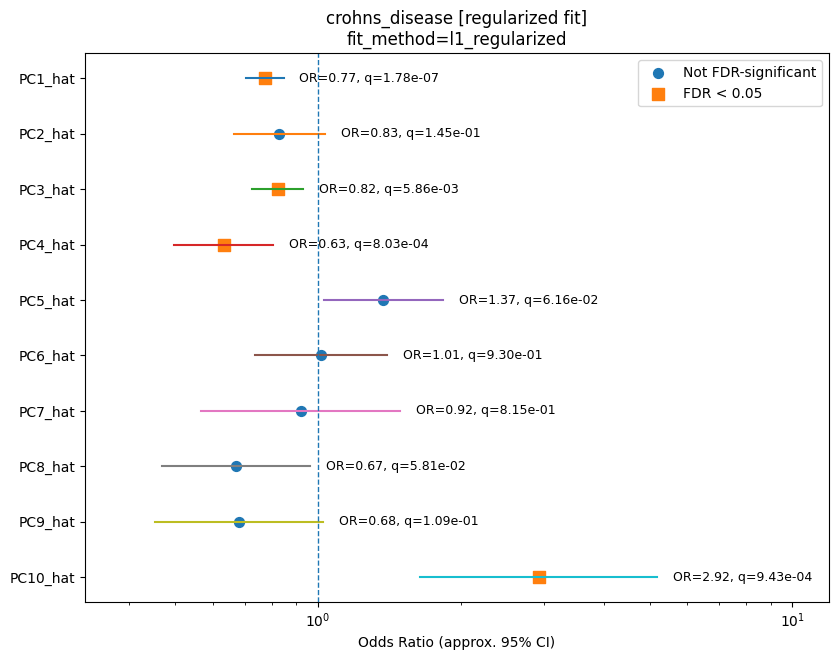

Saved: ./hongrui_result/UKB_RF_PCA_Projection/logistic_forest_plots/crohns_disease_forest_all_pcs.png


/tmp/ipykernel_3814848/3929294897.py:121: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sig_mask = sub["reject_FDR_0p05"].fillna(False).values if "reject_FDR_0p05" in sub.columns else np.zeros(len(sub), dtype=bool)


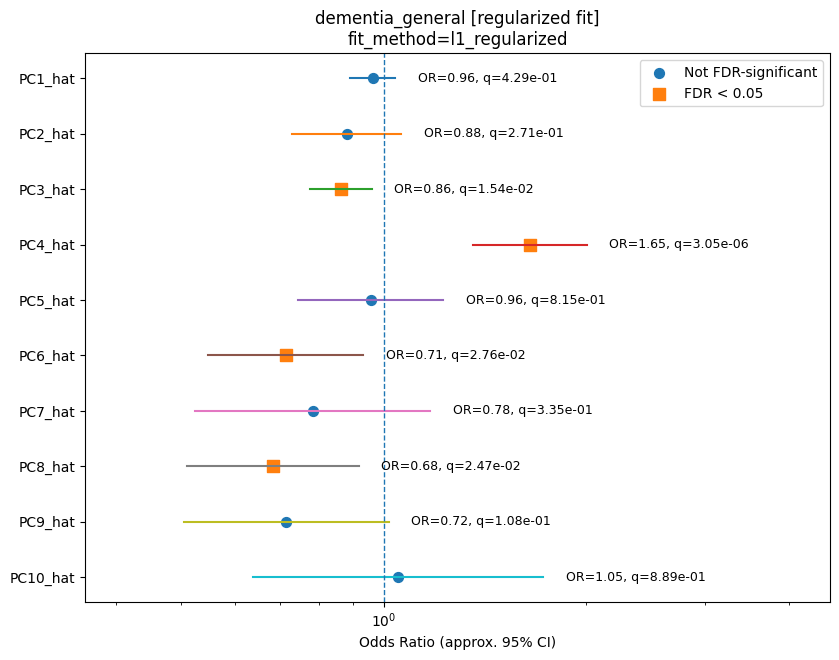

Saved: ./hongrui_result/UKB_RF_PCA_Projection/logistic_forest_plots/dementia_general_forest_all_pcs.png


/tmp/ipykernel_3814848/3929294897.py:121: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sig_mask = sub["reject_FDR_0p05"].fillna(False).values if "reject_FDR_0p05" in sub.columns else np.zeros(len(sub), dtype=bool)


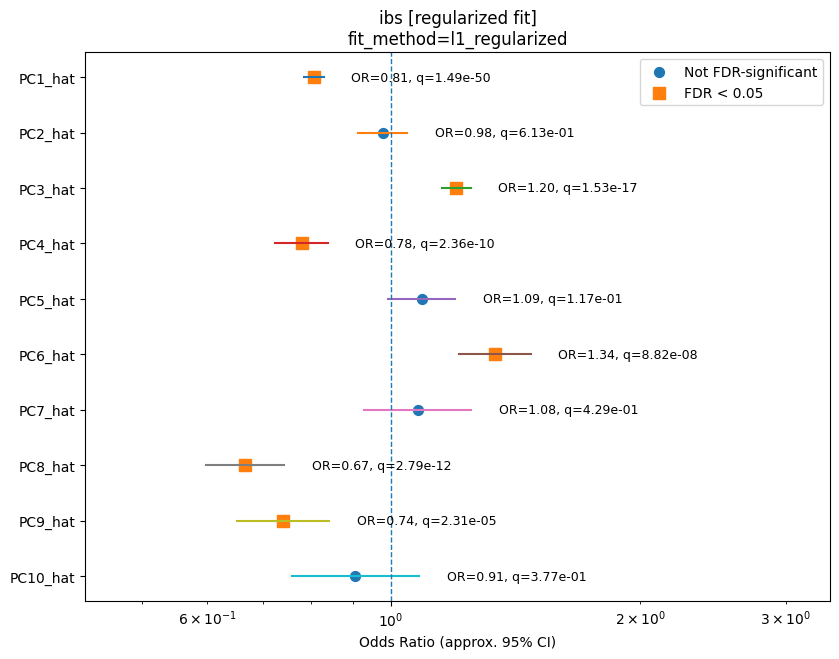

Saved: ./hongrui_result/UKB_RF_PCA_Projection/logistic_forest_plots/ibs_forest_all_pcs.png


/tmp/ipykernel_3814848/3929294897.py:121: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sig_mask = sub["reject_FDR_0p05"].fillna(False).values if "reject_FDR_0p05" in sub.columns else np.zeros(len(sub), dtype=bool)


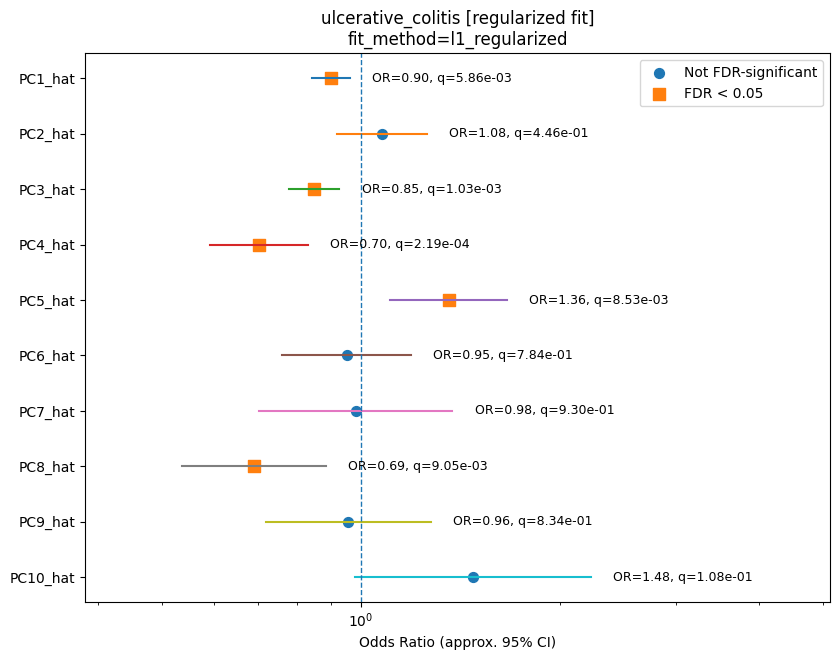

Saved: ./hongrui_result/UKB_RF_PCA_Projection/logistic_forest_plots/ulcerative_colitis_forest_all_pcs.png


/tmp/ipykernel_3814848/3929294897.py:121: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sig_mask = sub["reject_FDR_0p05"].fillna(False).values if "reject_FDR_0p05" in sub.columns else np.zeros(len(sub), dtype=bool)


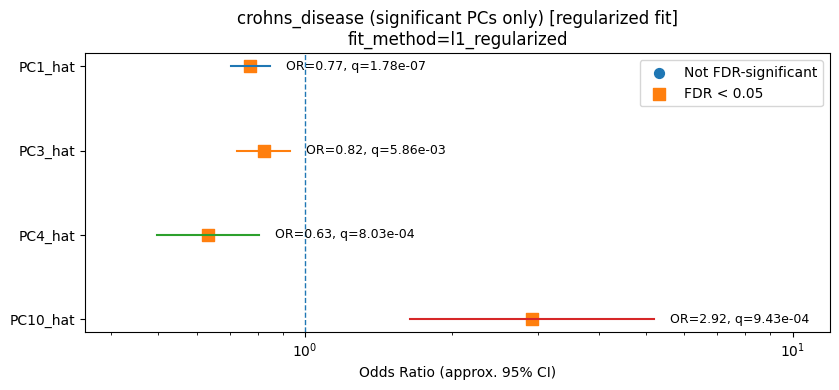

Saved: ./hongrui_result/UKB_RF_PCA_Projection/logistic_forest_plots/crohns_disease_forest_sig_only.png


/tmp/ipykernel_3814848/3929294897.py:121: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sig_mask = sub["reject_FDR_0p05"].fillna(False).values if "reject_FDR_0p05" in sub.columns else np.zeros(len(sub), dtype=bool)


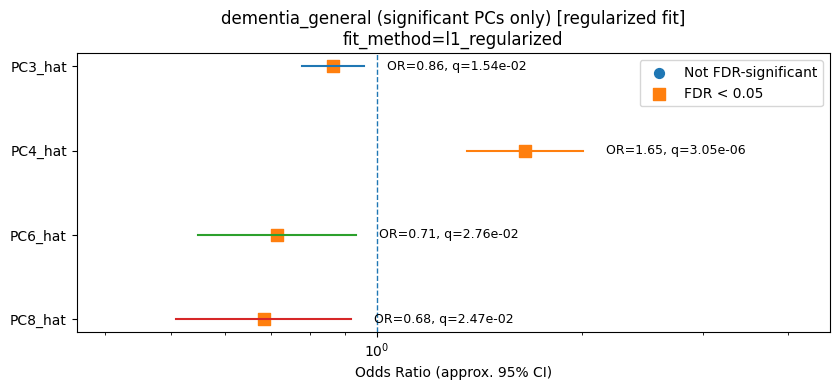

Saved: ./hongrui_result/UKB_RF_PCA_Projection/logistic_forest_plots/dementia_general_forest_sig_only.png


/tmp/ipykernel_3814848/3929294897.py:121: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sig_mask = sub["reject_FDR_0p05"].fillna(False).values if "reject_FDR_0p05" in sub.columns else np.zeros(len(sub), dtype=bool)


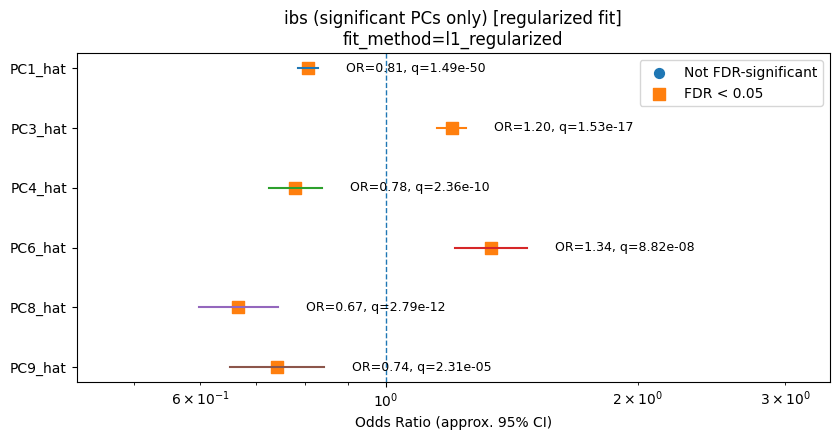

Saved: ./hongrui_result/UKB_RF_PCA_Projection/logistic_forest_plots/ibs_forest_sig_only.png


/tmp/ipykernel_3814848/3929294897.py:121: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sig_mask = sub["reject_FDR_0p05"].fillna(False).values if "reject_FDR_0p05" in sub.columns else np.zeros(len(sub), dtype=bool)


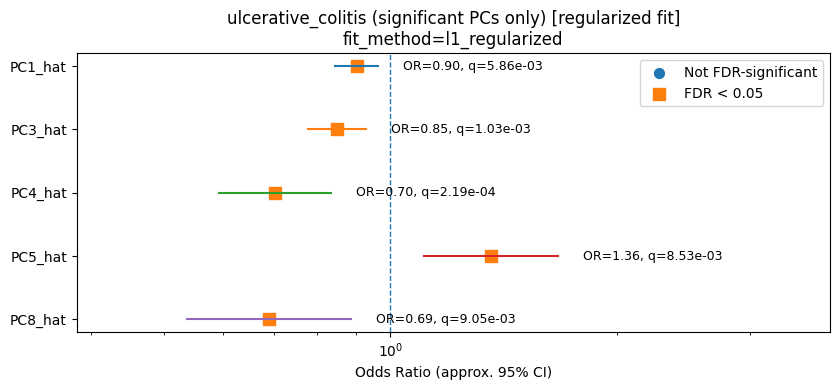

Saved: ./hongrui_result/UKB_RF_PCA_Projection/logistic_forest_plots/ulcerative_colitis_forest_sig_only.png


In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# ============================================================
# FOREST PLOTS FOR LOGISTIC REGRESSION RESULTS
# Uses your existing:
#   - pc_df
#   - outcome_df
#   - out_dir
# ============================================================

forest_out_dir = os.path.join(out_dir, "logistic_forest_plots")
os.makedirs(forest_out_dir, exist_ok=True)

# -----------------------------
# 1) Merge outcome-level fit info into pc_df
# -----------------------------
pc_forest_df = pc_df.copy()

if "fit_method" in outcome_df.columns:
    outcome_fit_info = outcome_df[["outcome", "fit_method", "used_regularized_fit"]].drop_duplicates()
    pc_forest_df = pc_forest_df.merge(outcome_fit_info, on="outcome", how="left")
else:
    pc_forest_df["fit_method"] = np.nan
    pc_forest_df["used_regularized_fit"] = np.nan

# -----------------------------
# 2) Clean numeric columns
# -----------------------------
pc_forest_df["coef_log_odds"] = pd.to_numeric(pc_forest_df["coef_log_odds"], errors="coerce")
pc_forest_df["p_value"] = pd.to_numeric(pc_forest_df["p_value"], errors="coerce")
pc_forest_df["q_value_BH"] = pd.to_numeric(pc_forest_df.get("q_value_BH", np.nan), errors="coerce")

# avoid p=0 or invalid values
pc_forest_df["p_value_clipped"] = pc_forest_df["p_value"].clip(lower=1e-300, upper=1.0)

# -----------------------------
# 3) Approximate SE and 95% CI from beta + p
#    z = norm.isf(p/2),  SE ~ |beta| / z
# -----------------------------
pc_forest_df["z_abs"] = norm.isf(pc_forest_df["p_value_clipped"] / 2.0)

pc_forest_df["se_approx"] = np.where(
    (pc_forest_df["z_abs"] > 0) & pc_forest_df["coef_log_odds"].notna(),
    np.abs(pc_forest_df["coef_log_odds"]) / pc_forest_df["z_abs"],
    np.nan
)

pc_forest_df["ci_low_logodds"] = pc_forest_df["coef_log_odds"] - 1.96 * pc_forest_df["se_approx"]
pc_forest_df["ci_high_logodds"] = pc_forest_df["coef_log_odds"] + 1.96 * pc_forest_df["se_approx"]

# odds ratio scale
pc_forest_df["odds_ratio"] = np.exp(pc_forest_df["coef_log_odds"])
pc_forest_df["or_low"] = np.exp(pc_forest_df["ci_low_logodds"])
pc_forest_df["or_high"] = np.exp(pc_forest_df["ci_high_logodds"])

# predictor order helper: PC1_hat, PC2_hat, ...
pc_forest_df["_pc_num"] = pd.to_numeric(
    pc_forest_df["predictor"].str.extract(r"PC(\d+)_hat")[0],
    errors="coerce"
)

# save full forest table
forest_table_path = os.path.join(forest_out_dir, "pc_forest_table_with_or_ci.csv")
pc_forest_df.to_csv(forest_table_path, index=False)
print("Saved forest plot table to:", forest_table_path)

# -----------------------------
# 4) Plot function
# -----------------------------
def make_forest_plot_for_outcome(
    df,
    outcome_name,
    significant_only=False,
    skip_regularized=False
):
    sub = df[df["outcome"] == outcome_name].copy()

    if sub.empty:
        print(f"[SKIP] No rows found for outcome={outcome_name}")
        return

    # optionally skip regularized outcomes
    used_reg = bool(sub["used_regularized_fit"].fillna(False).any())
    fit_method_label = sub["fit_method"].dropna().iloc[0] if sub["fit_method"].notna().any() else "unknown"

    if skip_regularized and used_reg:
        print(f"[SKIP] {outcome_name}: used_regularized_fit=True")
        return

    # optionally keep only FDR-significant rows
    if significant_only:
        if "reject_FDR_0p05" not in sub.columns:
            print(f"[SKIP] {outcome_name}: no reject_FDR_0p05 column")
            return
        sub = sub[sub["reject_FDR_0p05"] == True].copy()
        if sub.empty:
            print(f"[SKIP] {outcome_name}: no FDR-significant PCs")
            return

    # drop rows missing the key values
    sub = sub.dropna(subset=["odds_ratio", "or_low", "or_high", "_pc_num"])
    if sub.empty:
        print(f"[SKIP] {outcome_name}: no valid rows after filtering")
        return

    sub = sub.sort_values("_pc_num").reset_index(drop=True)
    y = np.arange(len(sub))

    fig_height = max(4, 0.55 * len(sub) + 1.2)
    fig, ax = plt.subplots(figsize=(8.5, fig_height))

    # CI lines
    for i, row in sub.iterrows():
        ax.plot([row["or_low"], row["or_high"]], [i, i], linewidth=1.5)

    # points: significant vs non-significant
    sig_mask = sub["reject_FDR_0p05"].fillna(False).values if "reject_FDR_0p05" in sub.columns else np.zeros(len(sub), dtype=bool)

    ax.scatter(
        sub.loc[~sig_mask, "odds_ratio"],
        y[~sig_mask],
        s=50,
        label="Not FDR-significant"
    )
    ax.scatter(
        sub.loc[sig_mask, "odds_ratio"],
        y[sig_mask],
        s=70,
        marker="s",
        label="FDR < 0.05"
    )

    # reference line at OR=1
    ax.axvline(1.0, linestyle="--", linewidth=1)

    # y labels
    ax.set_yticks(y)
    ax.set_yticklabels(sub["predictor"])
    ax.invert_yaxis()

    # log scale is usually nicer for OR forest plots
    ax.set_xscale("log")
    ax.set_xlabel("Odds Ratio (approx. 95% CI)")
    
    title_suffix = " (significant PCs only)" if significant_only else ""
    reg_suffix = " [regularized fit]" if used_reg else ""
    ax.set_title(f"{outcome_name}{title_suffix}{reg_suffix}\nfit_method={fit_method_label}")

    # annotate OR and q
    x_max = sub["or_high"].max()
    for i, row in sub.iterrows():
        q_text = f"{row['q_value_BH']:.2e}" if pd.notna(row.get("q_value_BH", np.nan)) else "NA"
        ax.text(
            row["or_high"] * 1.08,
            i,
            f"OR={row['odds_ratio']:.2f}, q={q_text}",
            va="center",
            fontsize=9
        )

    # expand limits for labels
    x_min = max(sub["or_low"].min() / 1.4, 1e-3)
    x_max = sub["or_high"].max() * 2.3
    ax.set_xlim(x_min, x_max)

    ax.legend()
    plt.tight_layout()

    suffix = "sig_only" if significant_only else "all_pcs"
    out_png = os.path.join(forest_out_dir, f"{outcome_name}_forest_{suffix}.png")
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", out_png)

# -----------------------------
# 5) Make plots for every outcome
# -----------------------------
all_outcomes_for_plot = sorted(pc_forest_df["outcome"].dropna().unique().tolist())

print("\nGenerating forest plots for outcomes:")
print(all_outcomes_for_plot)

for outcome_name in all_outcomes_for_plot:
    make_forest_plot_for_outcome(
        pc_forest_df,
        outcome_name,
        significant_only=False,
        skip_regularized=False
    )

for outcome_name in all_outcomes_for_plot:
    make_forest_plot_for_outcome(
        pc_forest_df,
        outcome_name,
        significant_only=True,
        skip_regularized=False
    )

[IBS boxplot] Top PC = PC1_hat | coef=-0.2149 | p=3.72e-52


/tmp/ipykernel_3814848/4179758305.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([vals_control, vals_ibs], labels=["Control", "IBS"], showfliers=False)


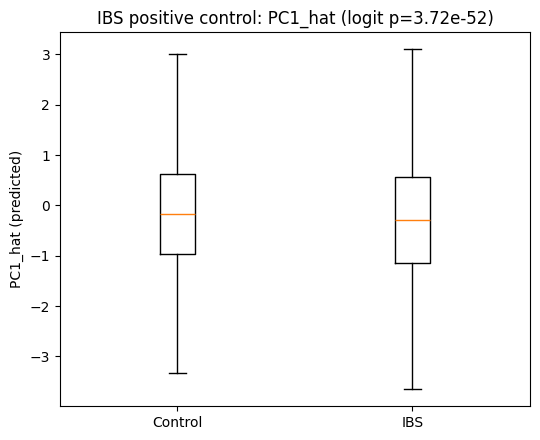

Saved: ./hongrui_result/UKB_RF_PCA_Projection/positive_control_boxplots/boxplot_IBS_PC1_hat.png
N control = 110364 | N IBS = 8084


In [15]:
# ============================================================
# Positive control visualization (IBS):
# Boxplot of Control vs Diseased for the most significant PC
# (picked from pc_df for outcome == "ibs")
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Choose the "top" PC for IBS (min p-value; fallback to |coef| if no p-values) ---
ibs_pc_stats = pc_df.loc[pc_df["outcome"].eq("ibs")].copy()
if ibs_pc_stats.shape[0] == 0:
    raise ValueError("No IBS rows found in pc_df (did the IBS logit run?).")

if ibs_pc_stats["p_value"].notna().any():
    ibs_pc_stats = ibs_pc_stats.sort_values("p_value", ascending=True)
else:
    ibs_pc_stats["abs_coef"] = ibs_pc_stats["coef_log_odds"].abs()
    ibs_pc_stats = ibs_pc_stats.sort_values("abs_coef", ascending=False)

top_pc = str(ibs_pc_stats.iloc[0]["predictor"])
top_p  = ibs_pc_stats.iloc[0]["p_value"] if "p_value" in ibs_pc_stats.columns else np.nan
top_b  = ibs_pc_stats.iloc[0]["coef_log_odds"] if "coef_log_odds" in ibs_pc_stats.columns else np.nan

print(f"[IBS boxplot] Top PC = {top_pc} | coef={top_b:.4g} | p={top_p:.3g}")

# --- 2) Rebuild the IBS modeling dataframe using the SAME complete-case logic as your logit ---
df_ibs = pd.concat(
    [
        ukb_df[["ibs"]].rename(columns={"ibs": "y"}),
        pc_hat_num,
        cov_df
    ],
    axis=1
).replace([np.inf, -np.inf], np.nan)

y_bin = coerce_binary(df_ibs["y"])
if y_bin is None:
    raise ValueError("ibs is not binary-coded as 0/1 or 1/2.")
df_ibs["y"] = y_bin

needed = ["y"] + pc_cols + cov_cols
df_ibs = df_ibs.dropna(subset=needed)

# --- 3) Boxplot: Control vs IBS for the top PC ---
box_dir = os.path.join(out_dir, "positive_control_boxplots")
os.makedirs(box_dir, exist_ok=True)

vals_control = df_ibs.loc[df_ibs["y"].eq(0), top_pc].astype(float).values
vals_ibs     = df_ibs.loc[df_ibs["y"].eq(1), top_pc].astype(float).values

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.boxplot([vals_control, vals_ibs], labels=["Control", "IBS"], showfliers=False)
ax.set_ylabel(f"{top_pc} (predicted)")
title = f"IBS positive control: {top_pc}"
if pd.notna(top_p):
    title += f" (logit p={top_p:.2e})"
ax.set_title(title)

plt.tight_layout()
out_png = os.path.join(box_dir, f"boxplot_IBS_{top_pc}.png")
plt.savefig(out_png, dpi=300)
plt.show()

print("Saved:", out_png)
print("N control =", len(vals_control), "| N IBS =", len(vals_ibs))

In [16]:
# ============================================================
# UKB COHORT FEATURE SUMMARY TABLES (paper-style)
# Put this AFTER Cell 2 in projection_RF_PCA.ipynb
# This summarizes the FILTERED UKB cohort currently stored in ukb_df
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 0) Output directory
# ------------------------------------------------------------
summary_dir = Path(out_dir) / "ukb_cohort_feature_summary"
summary_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1) Define feature groups from your notebook objects
# ------------------------------------------------------------
# INPUT FEATURES: same AGP-matched training columns used for RF projection
input_cols = list(train_cols)

# COVARIATES: use RAW covariates for paper table (not one-hot encoded dummies)
cov_num_cols = [c for c in globals().get("cov_num", []) if c in ukb_df.columns]
cov_cat_cols = [c for c in globals().get("cov_cat", []) if c in ukb_df.columns]

# OUTPUTS: continuous + binary outcomes used in your projection notebook
output_cont_cols = []
if "cognition_col" in globals() and cognition_col in ukb_df.columns:
    output_cont_cols.append(cognition_col)

default_binary_outcomes = [
    "ibs",
    "crohns_disease",
    "ulcerative_colitis",
    "dementia_general",
]

binary_outcome_cols = [
    c for c in globals().get("binary_outcomes", default_binary_outcomes)
    if c in ukb_df.columns
]

# Optional derived IBD-any variable if you want it in the summary
derived_outcomes = {}
if {"crohns_disease", "ulcerative_colitis"}.issubset(ukb_df.columns):
    crohns_tmp = pd.to_numeric(ukb_df["crohns_disease"], errors="coerce")
    uc_tmp     = pd.to_numeric(ukb_df["ulcerative_colitis"], errors="coerce")

    # handle either 0/1 or 1/2 encoding
    if set(crohns_tmp.dropna().unique()).issubset({1, 2}):
        crohns_tmp = crohns_tmp.map({1: 0, 2: 1})
    if set(uc_tmp.dropna().unique()).issubset({1, 2}):
        uc_tmp = uc_tmp.map({1: 0, 2: 1})

    ibd_any = np.where(
        crohns_tmp.isna() & uc_tmp.isna(),
        np.nan,
        ((crohns_tmp.fillna(0) == 1) | (uc_tmp.fillna(0) == 1)).astype(float)
    )
    derived_outcomes["ibd_any"] = pd.Series(ibd_any, index=ukb_df.index)

# ------------------------------------------------------------
# 2) Helper functions
# ------------------------------------------------------------
def pretty_name(x):
    return str(x).replace("_", " ").strip().capitalize()

def summarize_numeric(s, feature_name, group_name, available_in_ukb="Yes"):
    s = pd.to_numeric(s, errors="coerce")

    n_total = len(s)
    n_nonmiss = int(s.notna().sum())
    n_miss = int(s.isna().sum())
    pct_miss = 100 * n_miss / n_total if n_total > 0 else np.nan

    mean_val = s.mean()
    sd_val = s.std()
    median_val = s.median()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    min_val = s.min()
    max_val = s.max()

    return {
        "Group": group_name,
        "Feature": pretty_name(feature_name),
        "Original_feature_name": feature_name,
        "Level": "",
        "Available_in_UKB": available_in_ukb,
        "N": n_nonmiss,
        "Missing, n (%)": f"{n_miss} ({pct_miss:.1f}%)",
        "Mean (SD)": f"{mean_val:.2f} ({sd_val:.2f})" if pd.notna(mean_val) else "NA",
        "Median [IQR]": f"{median_val:.2f} [{q1:.2f}, {q3:.2f}]" if pd.notna(median_val) else "NA",
        "Range": f"{min_val:.2f} to {max_val:.2f}" if pd.notna(min_val) else "NA",
        "Count (%)": ""
    }

def summarize_categorical_levels(s, feature_name, group_name):
    s = s.astype("string")

    n_total = len(s)
    n_nonmiss = int(s.notna().sum())
    n_miss = int(s.isna().sum())
    pct_miss = 100 * n_miss / n_total if n_total > 0 else np.nan

    vc = s.dropna().value_counts(dropna=False)

    rows = []
    first = True
    for lvl, cnt in vc.items():
        pct = 100 * cnt / n_nonmiss if n_nonmiss > 0 else np.nan
        rows.append({
            "Group": group_name,
            "Feature": pretty_name(feature_name) if first else "",
            "Original_feature_name": feature_name if first else "",
            "Level": str(lvl),
            "Available_in_UKB": "Yes" if first else "",
            "N": n_nonmiss if first else "",
            "Missing, n (%)": f"{n_miss} ({pct_miss:.1f}%)" if first else "",
            "Mean (SD)": "",
            "Median [IQR]": "",
            "Range": "",
            "Count (%)": f"{int(cnt)} ({pct:.1f}%)"
        })
        first = False

    if len(rows) == 0:
        rows.append({
            "Group": group_name,
            "Feature": pretty_name(feature_name),
            "Original_feature_name": feature_name,
            "Level": "NA",
            "Available_in_UKB": "Yes",
            "N": 0,
            "Missing, n (%)": f"{n_miss} ({pct_miss:.1f}%)",
            "Mean (SD)": "",
            "Median [IQR]": "",
            "Range": "",
            "Count (%)": "0 (NA)"
        })

    return rows

def coerce_binary_for_summary(s):
    x = pd.to_numeric(s, errors="coerce")
    vals = sorted(pd.Series(x.dropna().unique()).tolist())

    if len(vals) == 0:
        return x
    if set(vals).issubset({0, 1}):
        return x
    if set(vals).issubset({1, 2}):
        return x.map({1: 0, 2: 1})
    if len(vals) == 2:
        # fallback: smaller value -> control, larger value -> case
        return x.map({vals[0]: 0, vals[1]: 1})
    return x

def summarize_binary(s, feature_name, group_name):
    x = coerce_binary_for_summary(s)

    n_total = len(x)
    n_nonmiss = int(x.notna().sum())
    n_miss = int(x.isna().sum())
    pct_miss = 100 * n_miss / n_total if n_total > 0 else np.nan

    case_n = int((x == 1).sum())
    control_n = int((x == 0).sum())
    case_pct = 100 * case_n / n_nonmiss if n_nonmiss > 0 else np.nan
    control_pct = 100 * control_n / n_nonmiss if n_nonmiss > 0 else np.nan

    return {
        "Group": group_name,
        "Feature": pretty_name(feature_name),
        "Original_feature_name": feature_name,
        "Level": "",
        "Available_in_UKB": "Yes",
        "N": n_nonmiss,
        "Missing, n (%)": f"{n_miss} ({pct_miss:.1f}%)",
        "Mean (SD)": "",
        "Median [IQR]": "",
        "Range": "",
        "Count (%)": f"Cases: {case_n} ({case_pct:.1f}%); Controls: {control_n} ({control_pct:.1f}%)"
    }

# ------------------------------------------------------------
# 3) INPUT FEATURE TABLE
#    Use AGP training columns; if UKB lacks a column, show 100% missing
# ------------------------------------------------------------
input_df = ukb_df.reindex(columns=input_cols).apply(pd.to_numeric, errors="coerce")
available_input_cols = set(ukb_df.columns)

input_rows = []
for col in input_cols:
    available_flag = "Yes" if col in available_input_cols else "No"
    input_rows.append(
        summarize_numeric(
            input_df[col],
            feature_name=col,
            group_name="Input features",
            available_in_ukb=available_flag
        )
    )

input_table = pd.DataFrame(input_rows)

# ------------------------------------------------------------
# 4) COVARIATE TABLE
# ------------------------------------------------------------
cov_rows = []

for col in cov_num_cols:
    cov_rows.append(
        summarize_numeric(
            ukb_df[col],
            feature_name=col,
            group_name="Covariates"
        )
    )

for col in cov_cat_cols:
    cov_rows.extend(
        summarize_categorical_levels(
            ukb_df[col],
            feature_name=col,
            group_name="Covariates"
        )
    )

covariate_table = pd.DataFrame(cov_rows)

# ------------------------------------------------------------
# 5) OUTPUT TABLE
# ------------------------------------------------------------
output_rows = []

# continuous outcomes
for col in output_cont_cols:
    output_rows.append(
        summarize_numeric(
            ukb_df[col],
            feature_name=col,
            group_name="Output features"
        )
    )

# binary outcomes from notebook
for col in binary_outcome_cols:
    output_rows.append(
        summarize_binary(
            ukb_df[col],
            feature_name=col,
            group_name="Output features"
        )
    )

# optional derived outcomes
for col, s in derived_outcomes.items():
    output_rows.append(
        summarize_binary(
            s,
            feature_name=col,
            group_name="Output features"
        )
    )

output_table = pd.DataFrame(output_rows)

# ------------------------------------------------------------
# 6) Keep paper-facing columns
# ------------------------------------------------------------
paper_cols = [
    "Feature", "Level", "Available_in_UKB", "N", "Missing, n (%)",
    "Mean (SD)", "Median [IQR]", "Range", "Count (%)"
]

input_paper = input_table[paper_cols].copy()
covariate_paper = covariate_table[paper_cols].copy()
output_paper = output_table[paper_cols].copy()

# ------------------------------------------------------------
# 7) Save CSV
# ------------------------------------------------------------
input_csv = summary_dir / "ukb_input_feature_summary.csv"
cov_csv = summary_dir / "ukb_covariate_summary.csv"
output_csv = summary_dir / "ukb_output_summary.csv"

input_full_csv = summary_dir / "ukb_input_feature_summary_full.csv"
cov_full_csv = summary_dir / "ukb_covariate_summary_full.csv"
output_full_csv = summary_dir / "ukb_output_summary_full.csv"

input_paper.to_csv(input_csv, index=False)
covariate_paper.to_csv(cov_csv, index=False)
output_paper.to_csv(output_csv, index=False)

input_table.to_csv(input_full_csv, index=False)
covariate_table.to_csv(cov_full_csv, index=False)
output_table.to_csv(output_full_csv, index=False)

# ------------------------------------------------------------
# 8) Save LaTeX
# ------------------------------------------------------------
with open(summary_dir / "ukb_input_feature_summary.tex", "w") as f:
    f.write(
        input_paper.to_latex(
            index=False,
            escape=False,
            longtable=True,
            caption="Summary of UK Biobank input features matched to AGP training variables.",
            label="tab:ukb_input_features"
        )
    )

with open(summary_dir / "ukb_covariate_summary.tex", "w") as f:
    f.write(
        covariate_paper.to_latex(
            index=False,
            escape=False,
            longtable=True,
            caption="Summary of UK Biobank covariate features used in downstream association models.",
            label="tab:ukb_covariates"
        )
    )

with open(summary_dir / "ukb_output_summary.tex", "w") as f:
    f.write(
        output_paper.to_latex(
            index=False,
            escape=False,
            longtable=True,
            caption="Summary of UK Biobank output variables used for projected microbiome association testing.",
            label="tab:ukb_outputs"
        )
    )

# ------------------------------------------------------------
# 9) Save one Excel workbook with 3 sheets
# ------------------------------------------------------------
xlsx_path = summary_dir / "ukb_cohort_feature_summary_tables.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    input_paper.to_excel(writer, sheet_name="Input_features", index=False)
    covariate_paper.to_excel(writer, sheet_name="Covariates", index=False)
    output_paper.to_excel(writer, sheet_name="Output_features", index=False)

# ------------------------------------------------------------
# 10) Print quick preview
# ------------------------------------------------------------
print("\n============================================================")
print("UKB COHORT FEATURE SUMMARY TABLES SAVED")
print("============================================================")
print(f"Input feature table:   {input_csv}")
print(f"Covariate table:       {cov_csv}")
print(f"Output feature table:  {output_csv}")
print(f"Excel workbook:        {xlsx_path}")

print("\n--- Preview: INPUT FEATURES ---")
print(input_paper.head(10).to_string(index=False))

print("\n--- Preview: COVARIATES ---")
print(covariate_paper.head(10).to_string(index=False))

print("\n--- Preview: OUTPUT FEATURES ---")
print(output_paper.head(10).to_string(index=False))


UKB COHORT FEATURE SUMMARY TABLES SAVED
Input feature table:   hongrui_result/UKB_RF_PCA_Projection/ukb_cohort_feature_summary/ukb_input_feature_summary.csv
Covariate table:       hongrui_result/UKB_RF_PCA_Projection/ukb_cohort_feature_summary/ukb_covariate_summary.csv
Output feature table:  hongrui_result/UKB_RF_PCA_Projection/ukb_cohort_feature_summary/ukb_output_summary.csv
Excel workbook:        hongrui_result/UKB_RF_PCA_Projection/ukb_cohort_feature_summary/ukb_cohort_feature_summary_tables.xlsx

--- Preview: INPUT FEATURES ---
                    Feature Level Available_in_UKB      N Missing, n (%)   Mean (SD)      Median [IQR]        Range Count (%)
        Alcohol consumption                    Yes 118422      26 (0.0%) 1.65 (0.60) 2.00 [1.00, 2.00] 0.00 to 2.00          
           Appendix removed                    Yes 118448       0 (0.0%) 0.01 (0.11) 0.00 [0.00, 0.00] 0.00 to 1.00          
                    Lactose                    Yes 118448       0 (0.0%) 0.00 (0.0